# Notebook 01 - Data Exploration (EDA)

**Project**: Predict Gallstone Disease from Clinical + Biompendance

**Notebook goals**
- Load & validate the dataset
- Perform thorough EDA (univariate, bivariate, corelations)
- Handle categorical encoding and scaling
- Save a provessed CSV for modeling notebooks

## Step 1: Import & Setup

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load Data

In [46]:
df = pd.read_csv("../data/raw/dataset-uci.csv")
df.head()
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.495298,0.500763,0.00,0.000,0.000000,1.000,1.00
Age,319.0,48.068966,12.114558,20.00,38.500,49.000000,56.000,96.00
Gender,319.0,0.492163,0.500724,0.00,0.000,0.000000,1.000,1.00
Comorbidity,319.0,0.335423,0.517340,0.00,0.000,0.000000,1.000,3.00
Coronary Artery Disease (CAD),319.0,0.037618,0.190568,0.00,0.000,0.000000,0.000,1.00
Hypothyroidism,319.0,0.028213,0.165841,0.00,0.000,0.000000,0.000,1.00
Hyperlipidemia,319.0,0.025078,0.156609,0.00,0.000,0.000000,0.000,1.00
Diabetes Mellitus (DM),319.0,0.134796,0.342042,0.00,0.000,0.000000,0.000,1.00
Height,319.0,167.156740,10.053030,145.00,159.500,168.000000,175.000,191.00
Weight,319.0,80.564890,15.709069,42.90,69.600,78.800000,91.250,143.50


comment on output

## Step 3: Check Missing Values & Duplicates

In [40]:
null = df.isnull().sum().sum()
duplicates = df.duplicated().sum()
print(f"Null values: {null}, Duplicates: {duplicates}")

Null values: 0, Duplicates: 0


Comment on output (there is 0 null values)

## Step 4: Explore the Target Variable

C:\Users\larso\AppData\Local\Temp\ipykernel_2024\2107640716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Gallstone Status", data=df, palette="Set2")


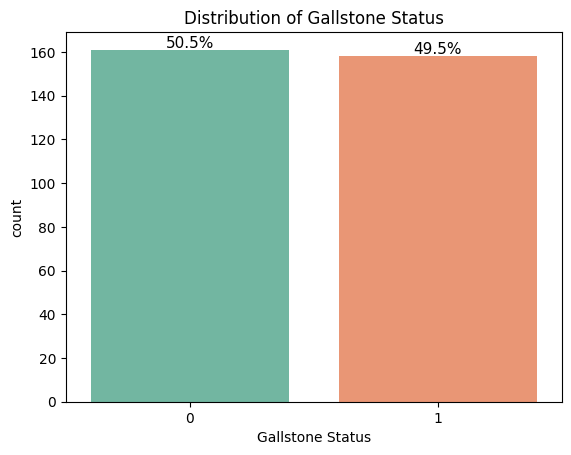

In [52]:
# Target distribution
ax = sns.countplot(x="Gallstone Status", data=df, palette="Set2")
plt.title("Distribution of Gallstone Status")
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 1,
        f"{(height / len(df) * 100):.1f}%",
        ha="center",
        fontsize=11,
    )
plt.show()



**Observation:**  
Classes are approximately balanced (~50% Yes / 50% No), which is ideal for binary classification. No class imbalance handling is needed.

## Step 5: Feature Overview and Grouping

In [22]:
demographics = ["Age", "Gender", "Height", "Weight", "Body Mass Index (BMI)"]

comorbidities = [
    "Comorbidity",
    "Coronary Artery Disease (CAD)",
    "Hypothyroidism",
    "Hyperlipidemia",
    "Diabetes Mellitus (DM)",
]

bioimpedance = [
    "Total Body Water (TBW)",
    "Extracellular Water (ECW)",
    "Intracellular Water (ICW)",
    "Extracellular Fluid/Total Body Water (ECF/TBW)",
    "Total Body Fat Ratio (TBFR) (%)",
    "Lean Mass (LM) (%)",
    "Body Protein Content (Protein) (%)",
    "Visceral Fat Rating (VFR)",
    "Bone Mass (BM)",
    "Muscle Mass (MM)",
    "Obesity (%)",
    "Total Fat Content (TFC)",
    "Visceral Fat Area (VFA)",
    "Visceral Muscle Area (VMA) (Kg)",
    "Hepatic Fat Accumulation (HFA)",
]

labs = [
    "Glucose",
    "Total Cholesterol (TC)",
    "Low Density Lipoprotein (LDL)",
    "High Density Lipoprotein (HDL)",
    "Triglyceride",
    "Aspartat Aminotransferaz (AST)",
    "Alanin Aminotransferaz (ALT)",
    "Alkaline Phosphatase (ALP)",
    "Creatinine",
    "Glomerular Filtration Rate (GFR)",
    "C-Reactive Protein (CRP)",
    "Hemoglobin (HGB)",
    "Vitamin D",
]

len(demographics) + len(comorbidities) + len(bioimpedance) + len(labs)

print(f"Total features: {len(df.columns) - 1}")
print(
    f"Demographics: {len(demographics)} | Comorbidities: {len(comorbidities)} | Bioimpedance: {len(bioimpedance)} | Labs: {len(labs)}"
)


Total features: 38
Demographics: 5 | Comorbidities: 5 | Bioimpedance: 15 | Labs: 13


**Observation:**  
Features are well distributed across clinical domains.  
This helps guide interpretation — e.g., *bioimpedance features* describe body composition, while *lab values* reflect biochemical health.

## Step 6: Univariate Analysis

<!-- ### Numeric features -->

### Demographics:

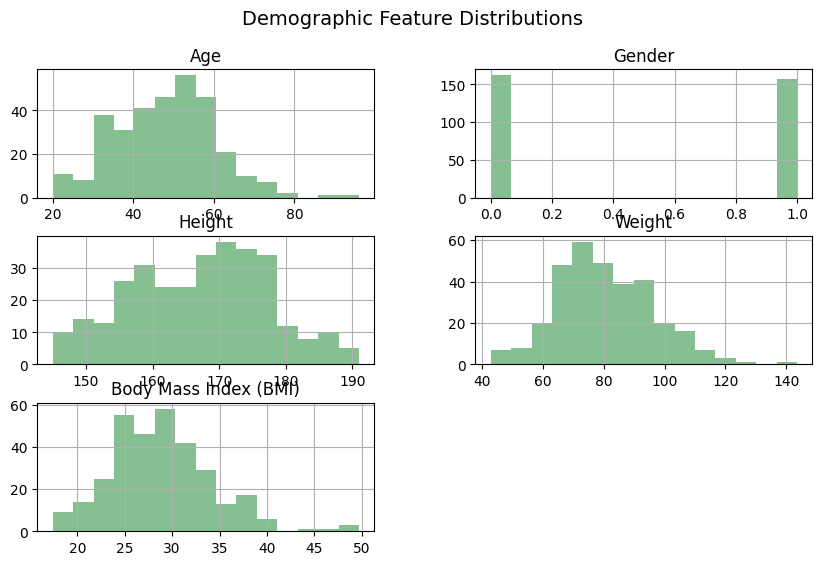

In [23]:
df[demographics].hist(figsize=(10, 6), bins=15, color="#86bf91")
plt.suptitle("Demographic Feature Distributions", fontsize=14)
plt.show()

### Bioimpedance:

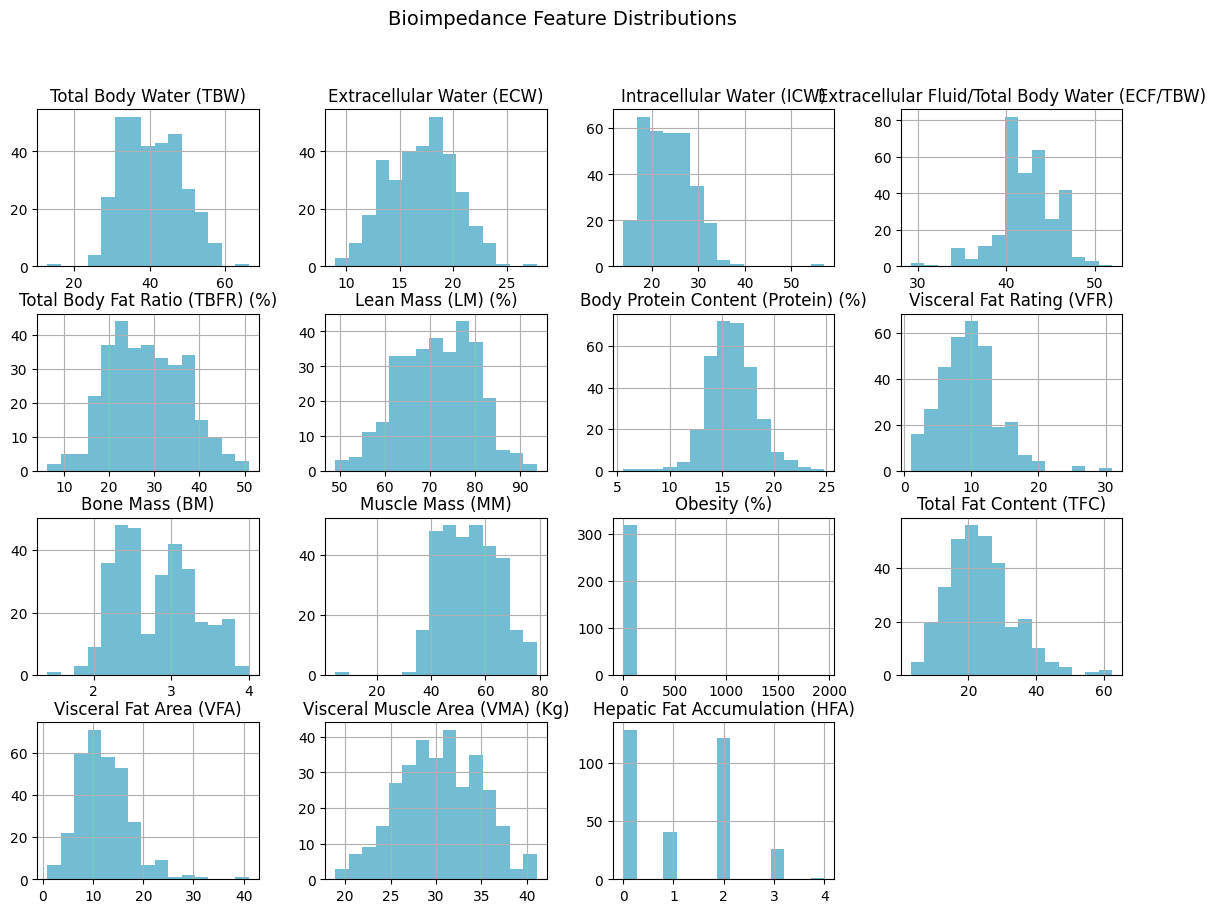

In [24]:
df[bioimpedance].hist(figsize=(14, 10), bins=15, color="#72bcd4")
plt.suptitle("Bioimpedance Feature Distributions", fontsize=14)
plt.show()

### Labs:

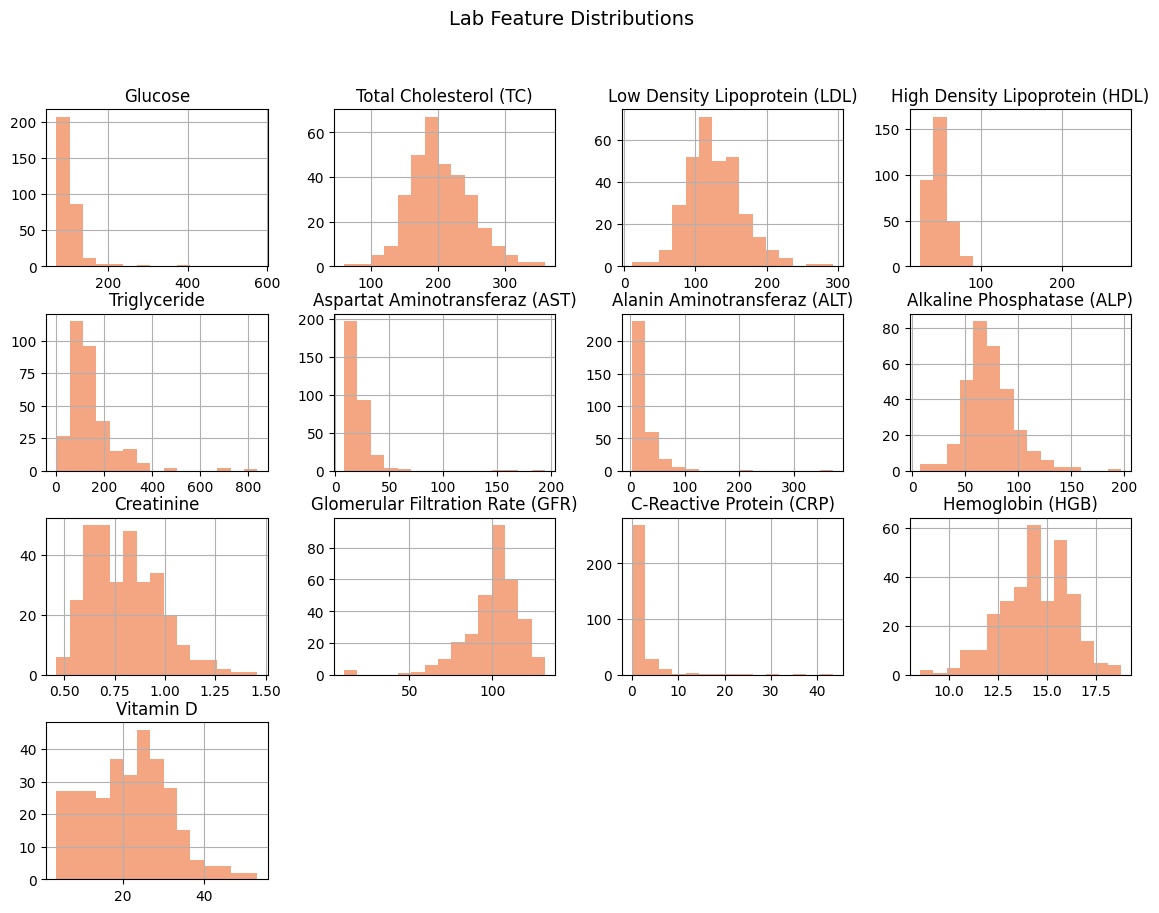

In [25]:
df[labs].hist(figsize=(14, 10), bins=15, color="#f4a582")
plt.suptitle("Lab Feature Distributions", fontsize=14)
plt.show()

comment on output

## Step 7: Bivariate Analysis

### Demographics vs Gallstone

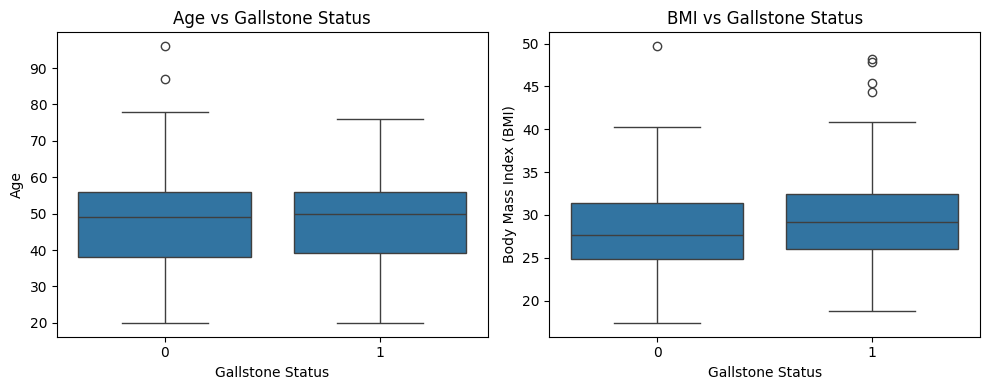

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x="Gallstone Status", y="Age", data=df, ax=axes[0])
sns.boxplot(x="Gallstone Status", y="Body Mass Index (BMI)", data=df, ax=axes[1])
axes[0].set_title("Age vs Gallstone Status")
axes[1].set_title("BMI vs Gallstone Status")
plt.tight_layout()
plt.show()


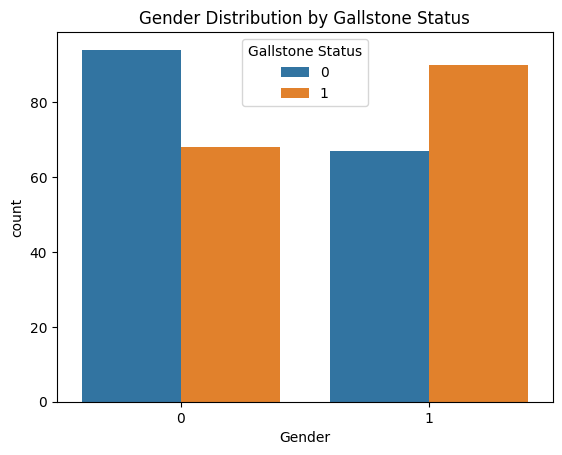

In [27]:
sns.countplot(x="Gender", hue="Gallstone Status", data=df)
plt.title("Gender Distribution by Gallstone Status")
plt.show()

comment on output

### Bioimpendence vs Gallstone

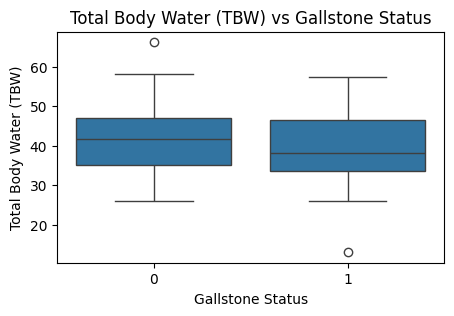

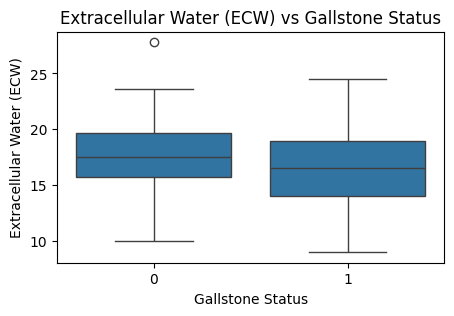

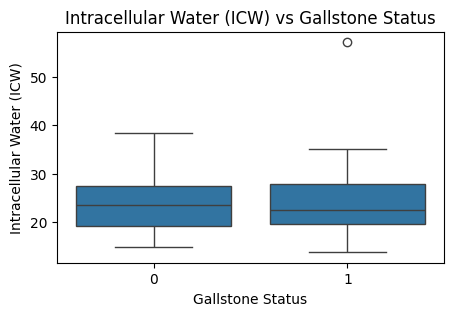

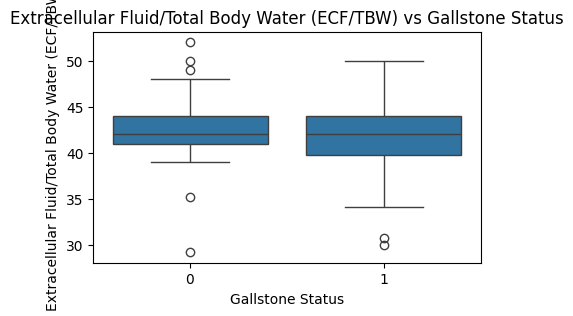

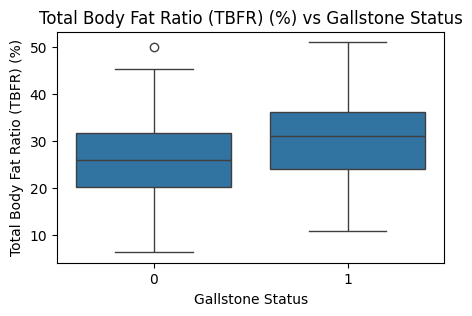

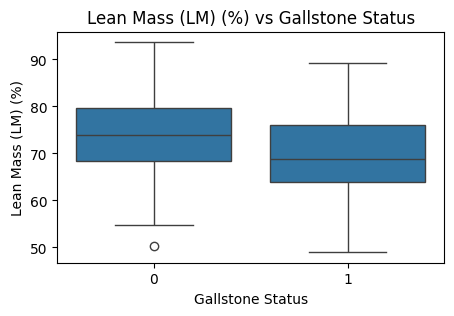

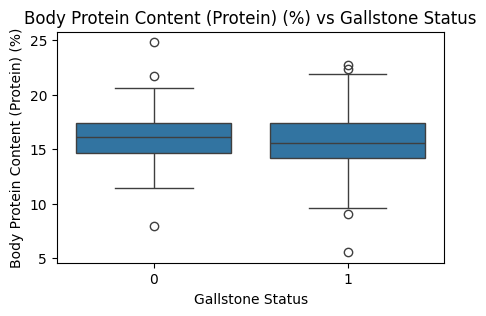

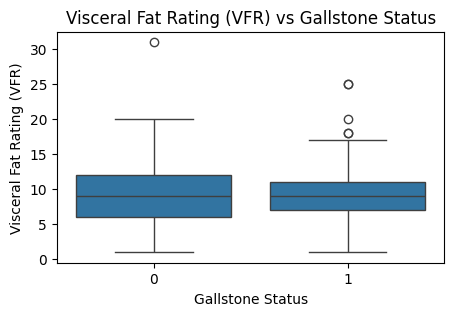

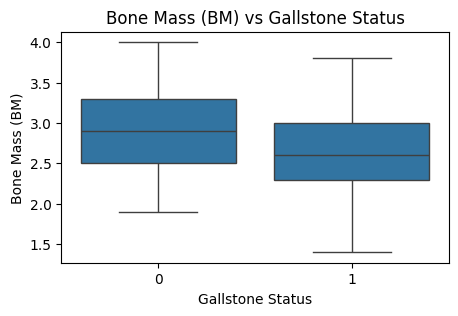

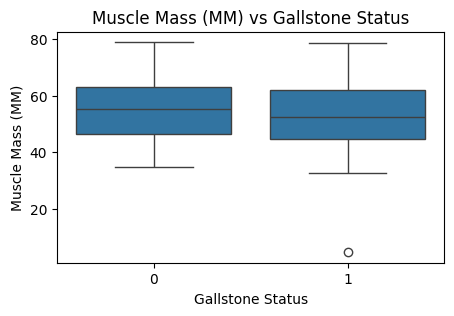

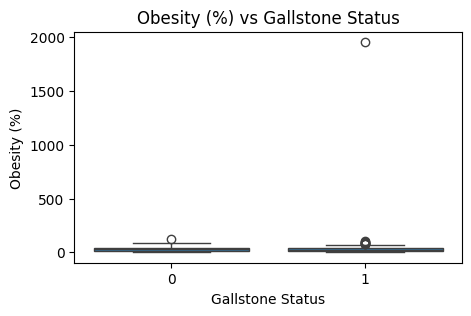

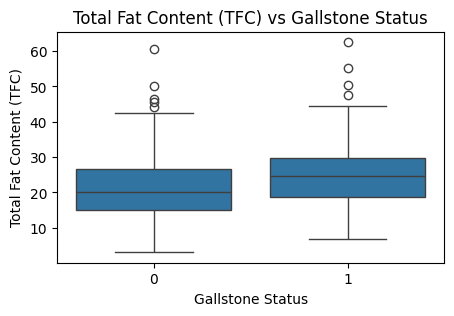

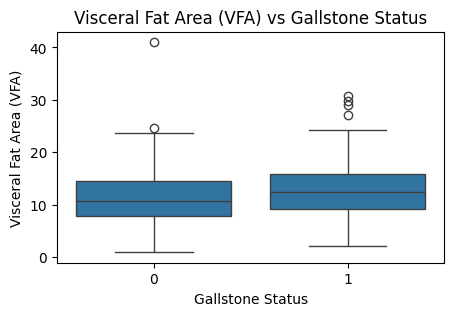

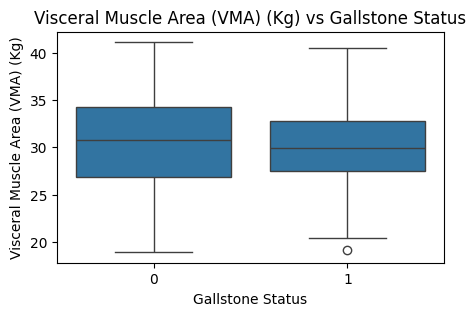

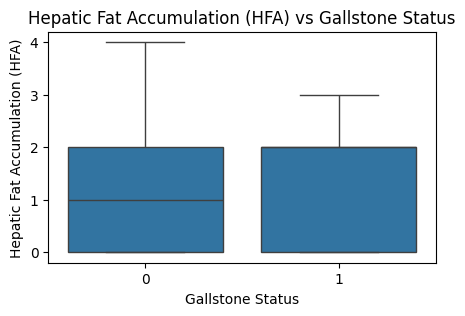

In [28]:
for col in bioimpedance:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x="Gallstone Status", y=col, data=df)
    plt.title(f"{col} vs Gallstone Status")
    plt.show()


comment on output

### Lab Values vs Gallstone

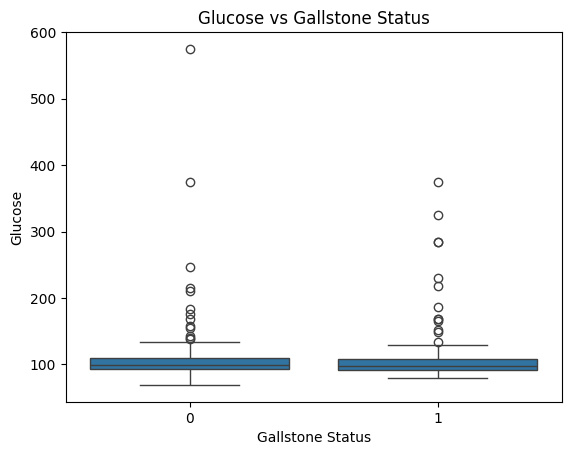

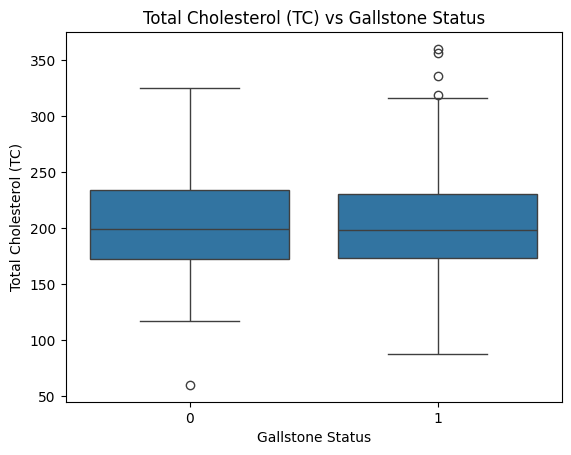

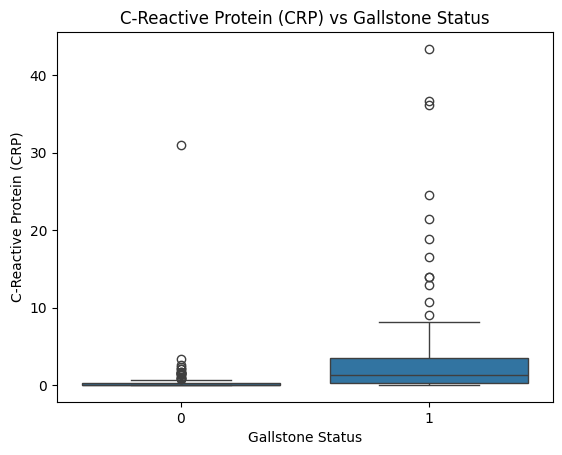

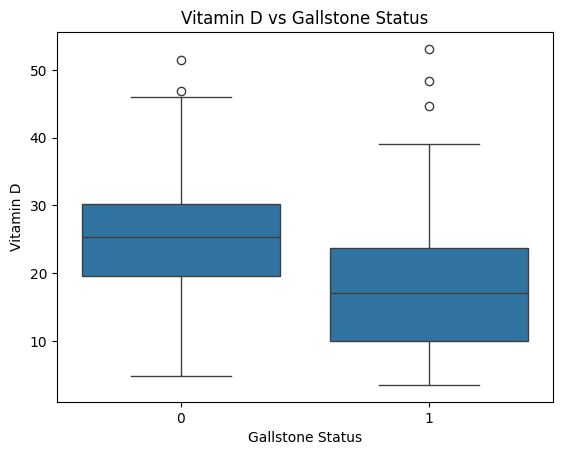

In [29]:
key_labs = ["Glucose", "Total Cholesterol (TC)", "C-Reactive Protein (CRP)", "Vitamin D"]
for col in key_labs:
    sns.boxplot(x="Gallstone Status", y=col, data=df)
    plt.title(f"{col} vs Gallstone Status")
    plt.show()


comment on output

## Step 8: Correlation Analysis

C:\Users\larso\AppData\Local\Temp\ipykernel_2024\1857690555.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target, y=corr_with_target.index, palette="coolwarm")


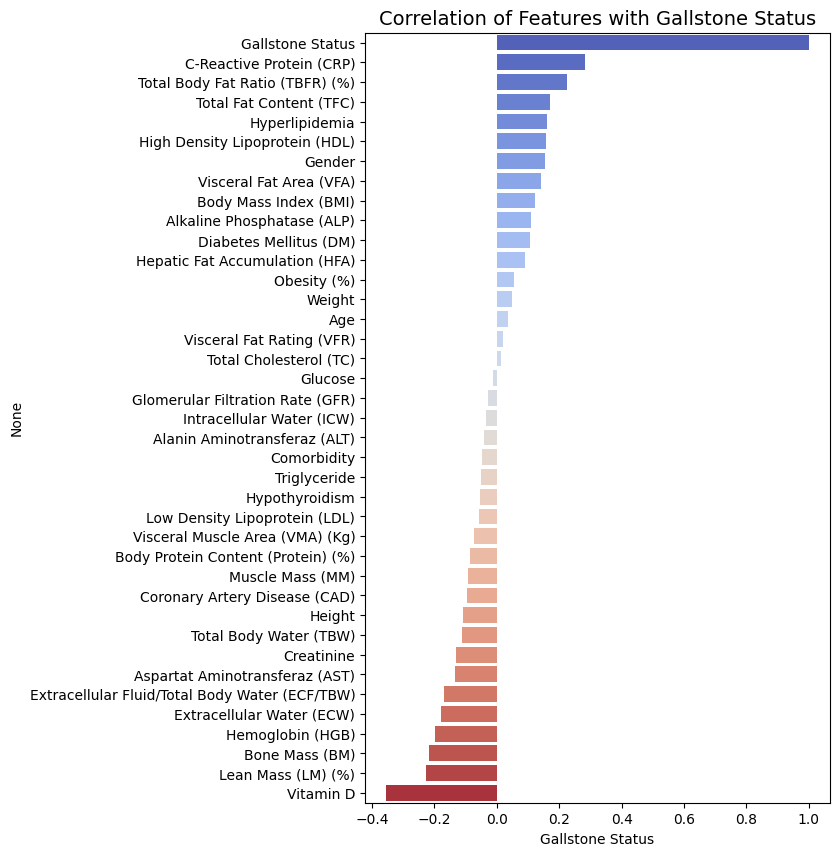

In [30]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_with_target = numeric_df.corr()['Gallstone Status'].sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.barplot(x=corr_with_target, y=corr_with_target.index, palette="coolwarm")
plt.title("Correlation of Features with Gallstone Status", fontsize=14)
plt.show()


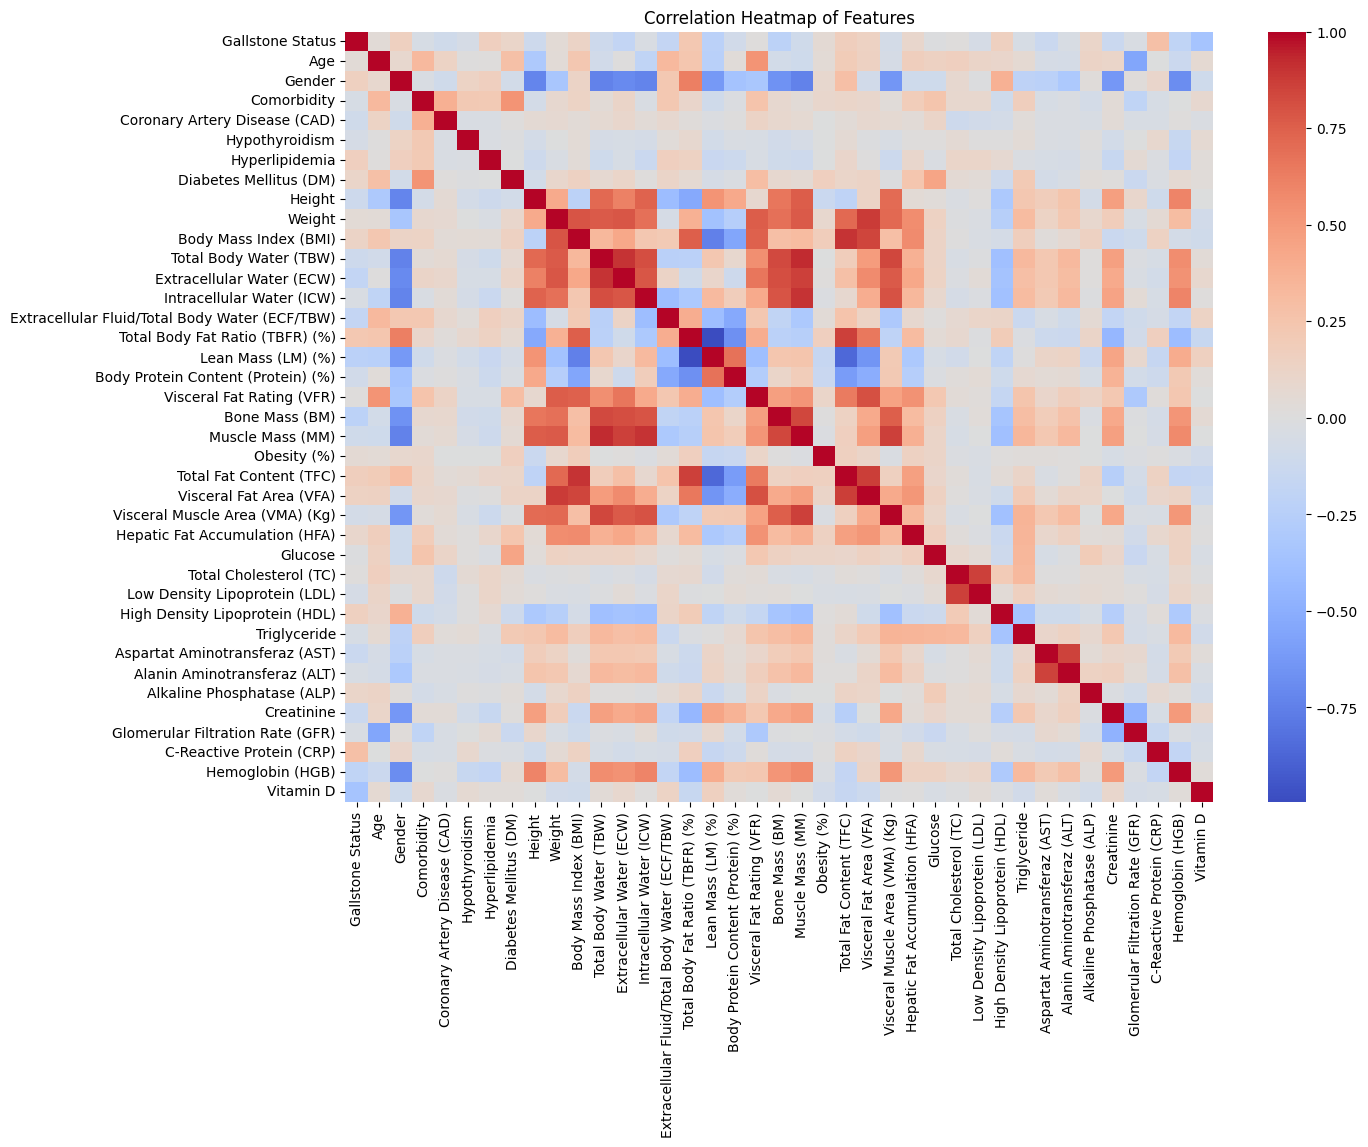

In [31]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.show()

comment on output

## Step 9: Summary & Insights


1. **Target:** Balanced classes (~50% positive).  
2. **Demographics:** Older age and higher BMI correlate with gallstones.  
3. **Bioimpedance:** Visceral fat, hepatic fat, and total body fat metrics higher in gallstone-positive patients.  
4. **Labs:** CRP elevated, Vitamin D slightly lower in positive cases. Lipids show moderate differences.  
5. **Correlations:** Some multicollinearity among bioimpedance metrics, but target-related signals are clear.  
6. **Dataset Quality:** No missing values, reasonable distributions, ready for feature scaling and encoding.

**Next Step:** Encode categorical variables, standardize continuous features, and prepare the dataset for modeling in Notebook 2.